<a href="https://colab.research.google.com/github/mptorpo/integracion_prospectiva_y_datos/blob/main/Reto_4_Integracion_Multidimensional_Miguel_Pimiento_Restrepo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Reto 4 – Integración Multidimensional**

- Miguel Pimiento Restrepo
- Epik ID: 1000293648

Una entidad del sector Fintech requiere reducir el número de sucursales en las cuales atiende a cada uno de sus solicitantes de crédito, para lo cual la entidad financiera quiere llevar a cabo un proceso de integración multidimensional de los datos a cinco sucursales. Se debe determinar para cada sucursal el número de clientes, los municipios de procedencia y el porcentaje de preaprobación o prenegación.

**Variables**
- Edad: Número de años cumplidos del solicitante; indica su etapa de vida y puede influir en su perfil de riesgo crediticio.
- Hijos: Cantidad de hijos del solicitante; refleja responsabilidades familiares que pueden afectar su capacidad de pago.
- Personas a Cargo: Número de personas que dependen económicamente del solicitante (incluye hijos u otros dependientes).
- Estrato: Clasificación socioeconómica del hogar (usada en países como Colombia) que indica el nivel de ingresos y condiciones de vida.
- Ingresos: Total de dinero que percibe el solicitante en un periodo determinado (generalmente mensual).
- Egresos: Total de gastos o salidas de dinero del solicitante en un periodo determinado.
- Monto: Valor total del crédito solicitado.
- Plazo: Tiempo acordado para el pago del crédito, usualmente expresado en meses.
- Cuota del Crédito: Valor que el solicitante debe pagar periódicamente (generalmente mensual) para amortizar el crédito, incluyendo capital e intereses.

**0. Se procede con la carga de las librerías de trabajo**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Se procede con la carga del archivo de trabajo**

In [ ]:
nxl = '/content/drive/MyDrive/Colab Notebooks/4. SolicitantesCrédito(USD)_Municipios.xlsx'
XDB = pd.read_excel(nxl)

#Se ofuscan los datos
XDB = XDB.sample(frac=1, random_state=42).reset_index(drop=True)
XDB.dropna()

print('Dimensiones de la base de datos:', XDB.shape)
print('Columnas:', XDB.columns.tolist())
XDB.head()

Dimensiones de la base de datos: (5842, 38)
Columnas: ['Cédula', 'Edad', 'Sexo', 'Estado civil', 'Hijos', 'Perscargo', 'Nivel Renta', 'Estrato', 'Nivel de estudios', 'Tipo de contrato', 'Ingresos', 'Egresos', 'Tipo de actividad', 'Tipo de vivienda', 'Total Activos', 'Total pasivos', 'Salario', 'Ingresos por arriendo', 'Ingresos por honorarios', 'Ingresos financieros', 'Otros ingresos', 'Gasto familiar', 'Gasto obligatorio', 'Gasto arriendo', 'Otros gastos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)', 'ConoCliente', 'Garantia', 'RespPat', 'MoraCome', 'PreApr', 'Prob.Default (PD)', 'Score', 'LGD', 'Net_Income', 'Municipio']


,Cédula,Edad,Sexo,Estado civil,Hijos,Perscargo,Nivel Renta,Estrato,Nivel de estudios,Tipo de contrato,...,ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD,Net_Income,Municipio
0,6556,63,NR,Unión Libre,1,1,1,3,Bachiller,Ninguno,...,Buenas Referencias,Fondo de Garantia,Sin Patrimonio,Con Experiencia sin Mora,0,0.233305,474.284668,0.473965,94.814667,Caldas
1,239,31,Mujer,Soltero,0,1,1,2,Tecnólogo,Indefinido,...,Buena Experiencia CFB,Fondo de Garantia,Prop.sin Hipoteca,Con Experiencia sin Mora,0,0.254857,322.984283,0.386951,-59.363306,Caldas
2,226,61,NR,Casado,7,3,3,2,Tecnólogo,Indefinido,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.089151,619.955383,0.156131,175.430444,Sabaneta
3,8017,42,Mujer,Soltero,2,1,1,3,Tecnólogo,Fijo,...,Buena Experiencia CFB,Libranza Establecida,Sin Patrimonio,Una mora 60 Dìas,0,0.157716,486.018250,0.292610,265.696222,Caldas
4,3334,32,Mujer,Soltero,1,1,1,4,Bachiller,Indefinido,...,Buenas Referencias,Fondo de Garantia,Sin Patrimonio,Con Experiencia sin Mora,0,0.089574,517.180481,0.155736,406.870611,Itagüí


**Análisis de Resultados**

Los cinco primeros registros de la base de datos, van a convertirse en las semillas de integración de los datos para el modelo K-Medoids (Integración Dinámica Multidimensional). Las variables numéricas seleccionadas para la integración son: Edad, Hijos, Perscargo, Estrato, Ingresos, Egresos, Monto (EAD), Plazo, Cuota (COP).

**2. Se crean las semillas de integración y se ejecuta el modelo K-Medoids**

In [ ]:
#Se seleccionan las variables numéricas para la integración
variables = ['Edad', 'Hijos', 'Perscargo', 'Estrato', 'Ingresos', 'Egresos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)']

#Se extraen las variables numéricas como arrays de numpy
XD = np.array(XDB[variables])  #Todos los datos - Solo variables numéricas
XC = np.array(XDB[variables].iloc[0:5])  #Semillas de integración - Los primeros 5 datos (CENTROIDES)

nc = np.zeros((len(XD), 1))

#Se procede con la integración
for k in range(len(XD)):
    Xind = XD[k,]  #Se clasifica al individuo k - XIND = INDIVIDUO

    #Se calcula la distancia relativa al cuadrado contra cada centroide
    #Se usa np.where para evitar la división por cero en los centroides
    denominador = np.where(XC[:, ] == 0, 0.0001, XC[:, ])
    m1 = np.sum(((XC[:, ] - Xind) / denominador)**2, axis=1)

    nc[k] = np.argmin(m1)  #Se asigna al cluster más cercano
    cluster = int(np.argmin(m1))

    #Se actualiza el centroide con el promedio móvil
    XC[cluster, ] = (XC[cluster, ] + Xind) / 2

print('Integración completada.')
print('Forma de los centroides finales:', XC.shape)

Integración completada.
Forma de los centroides finales: (5, 9)


**3. Se determinan los resultados por cluster: número de clientes, municipios y preaprobación**

In [ ]:
#Se construye un DataFrame con los centroides finales
dfxc = pd.DataFrame(XC)
dfxc.columns = variables

ND = []   #Número de datos por cluster
PA = []   #Porcentaje de preaprobación por cluster
PN = []   #Porcentaje de prenegación por cluster

for j in range(5):
    filas = np.where(nc[:, ] == j)[0]  #Filas de las personas de un cluster
    nd = len(filas)

    #Se calcula el porcentaje de preaprobación y prenegación
    n_preaprobados = len(np.where(XDB.iloc[filas]['PreApr'] == 1)[0])
    n_prenegados = len(np.where(XDB.iloc[filas]['PreApr'] == 0)[0])
    pct_preaprobacion = round((n_preaprobados / nd) * 100, 2)
    pct_prenegacion = round((n_prenegados / nd) * 100, 2)

    print(f'--- Cluster (Sucursal) {j} ---')
    print(f'Número de clientes: {nd}')
    print(f'Preaprobados: {n_preaprobados} ({pct_preaprobacion}%)')
    print(f'Prenegados: {n_prenegados} ({pct_prenegacion}%)')

    #Se muestran los municipios de procedencia
    municipios = XDB.iloc[filas]['Municipio'].value_counts()
    print(f'Municipios de procedencia:')
    for mun, count in municipios.items():
        print(f'  {mun}: {count} solicitantes')
    print()

    ND.append(nd)
    PA.append(pct_preaprobacion)
    PN.append(pct_prenegacion)

dfxc['NDatos'] = ND
dfxc['% PreAprobación'] = PA
dfxc['% PreNegación'] = PN
display(dfxc)

--- Cluster (Sucursal) 0 ---
Número de clientes: 123
Preaprobados: 23 (18.7%)
Prenegados: 100 (81.3%)
Municipios de procedencia:
  Caldas: 83 solicitantes
  Itagüí: 15 solicitantes
  Sabaneta: 13 solicitantes
  Bello: 9 solicitantes
  Medellín: 2 solicitantes
  Envigado: 1 solicitantes

--- Cluster (Sucursal) 1 ---
Número de clientes: 44
Preaprobados: 11 (25.0%)
Prenegados: 33 (75.0%)
Municipios de procedencia:
  Caldas: 29 solicitantes
  Itagüí: 5 solicitantes
  Bello: 5 solicitantes
  Sabaneta: 4 solicitantes
  Medellín: 1 solicitantes

--- Cluster (Sucursal) 2 ---
Número de clientes: 5359
Preaprobados: 2728 (50.91%)
Prenegados: 2631 (49.09%)
Municipios de procedencia:
  Sabaneta: 1715 solicitantes
  Caldas: 1626 solicitantes
  Bello: 987 solicitantes
  Itagüí: 534 solicitantes
  Medellín: 422 solicitantes
  Envigado: 75 solicitantes

--- Cluster (Sucursal) 3 ---
Número de clientes: 215
Preaprobados: 83 (38.6%)
Prenegados: 132 (61.4%)
Municipios de procedencia:
  Caldas: 101 solicita

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP),NDatos,% PreAprobación,% PreNegación
0,38.833495,1.784844e-25,1.880791e-37,2.058571,219.065456,157.708670,219.186553,32.182440,8.564546,123,18.70,81.30
1,45.659730,0.000000e+00,5.949119e-09,3.122924,7.542339,5.809386,4.073477,33.355430,0.170723,44,25.00,75.00
2,27.172960,1.539585e-01,1.563630e+00,2.045467,490.902385,514.509391,333.741282,23.138103,30.648833,5359,50.91,49.09
3,62.557573,8.951575e-29,5.317518e-64,1.632118,37.964387,38.349475,25.220723,23.568435,1.269565,215,38.60,61.40
4,56.190774,9.466331e-30,1.577722e-30,3.390450,34.403579,39.667950,16.840429,34.290079,0.632009,101,37.62,62.38


**4. Se representan los clusters mediante gráficos de araña (radar)**

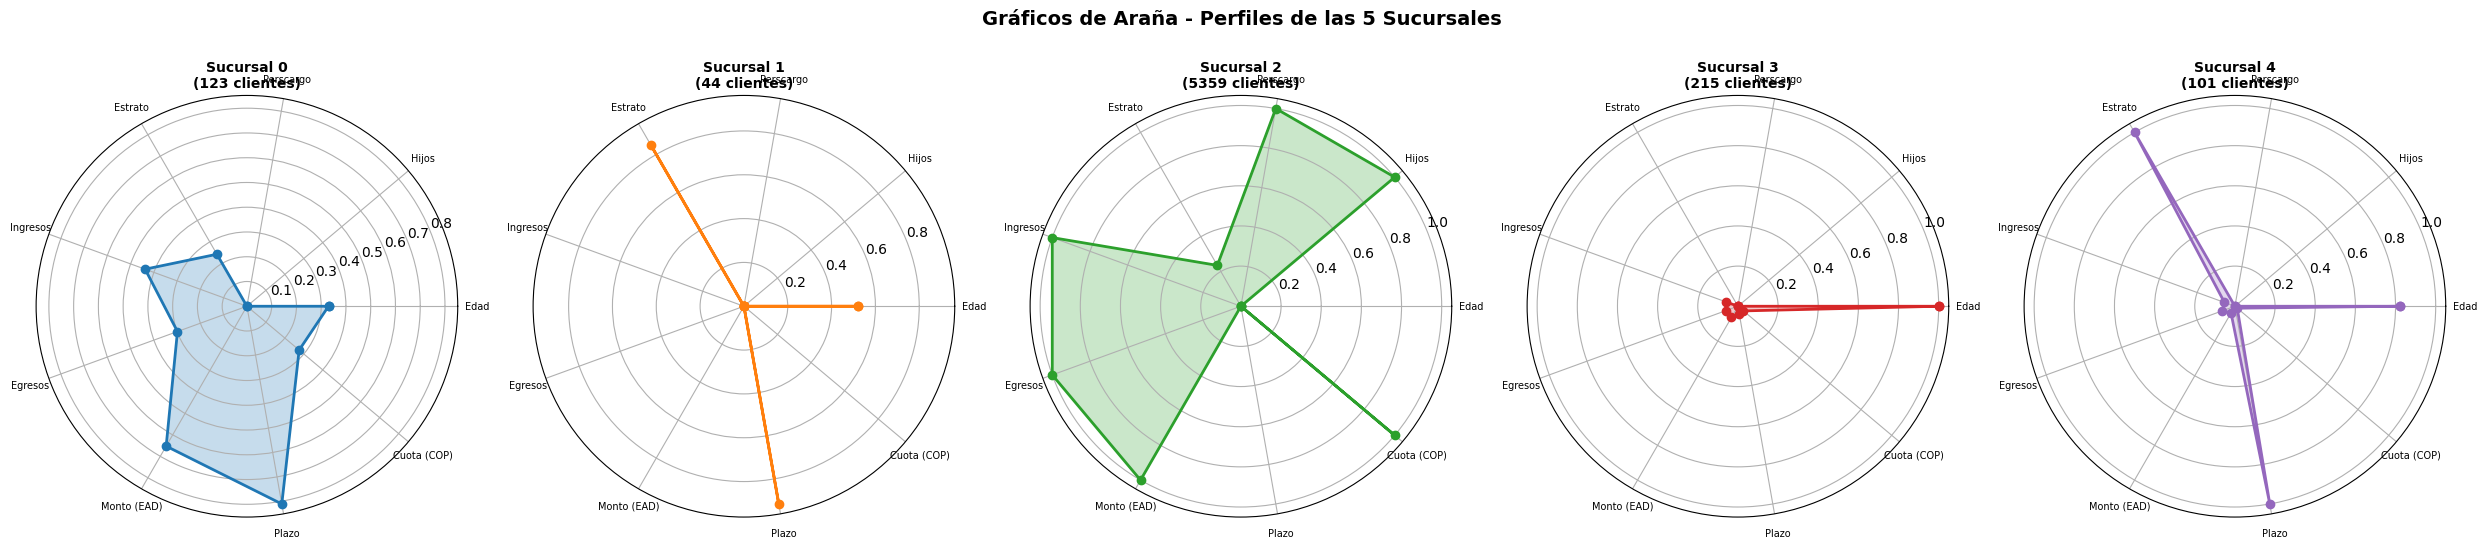

In [ ]:
#Se normalizan los centroides para una mejor visualización en el gráfico de araña
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
XC_norm = scaler.fit_transform(XC)
dfxc_norm = pd.DataFrame(XC_norm, columns=variables)

#Se crean los gráficos de araña para cada cluster
fig, axes = plt.subplots(1, 5, figsize=(25, 5), subplot_kw=dict(polar=True))
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for j in range(5):
    ax = axes[j]
    valores = dfxc_norm.iloc[j].values.tolist()
    valores += valores[:1]  #Se cierra el polígono

    angulos = np.linspace(0, 2 * np.pi, len(variables), endpoint=False).tolist()
    angulos += angulos[:1]  #Se cierra el polígono

    ax.plot(angulos, valores, 'o-', linewidth=2, color=colores[j])
    ax.fill(angulos, valores, alpha=0.25, color=colores[j])
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(variables, fontsize=7)
    ax.set_title(f'Sucursal {j}\n({ND[j]} clientes)', fontsize=10, fontweight='bold')

plt.suptitle('Gráficos de Araña - Perfiles de las 5 Sucursales', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('radar_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**5. Se representa un gráfico de araña consolidado con todas las sucursales**

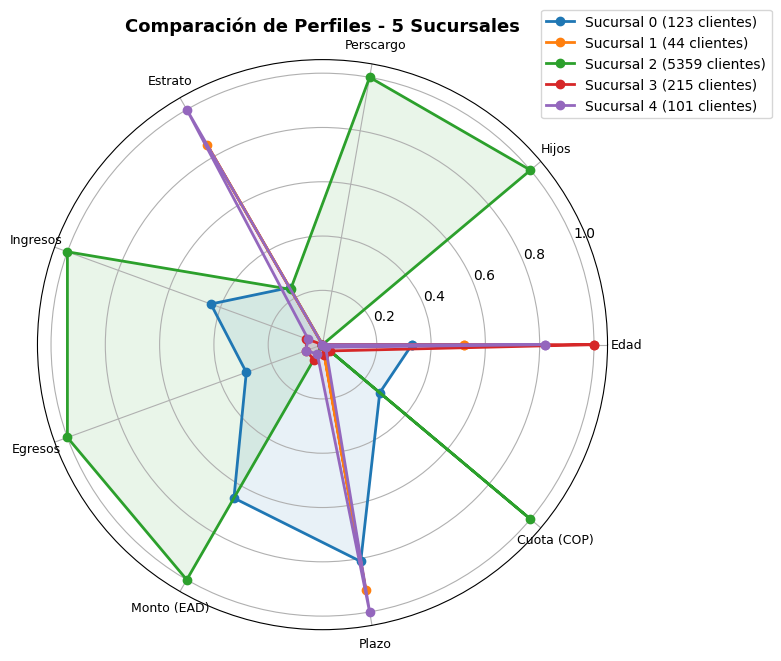

In [ ]:
#Gráfico de araña consolidado
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

angulos = np.linspace(0, 2 * np.pi, len(variables), endpoint=False).tolist()
angulos += angulos[:1]

for j in range(5):
    valores = dfxc_norm.iloc[j].values.tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, 'o-', linewidth=2, color=colores[j], label=f'Sucursal {j} ({ND[j]} clientes)')
    ax.fill(angulos, valores, alpha=0.1, color=colores[j])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(variables, fontsize=9)
ax.set_title('Comparación de Perfiles - 5 Sucursales', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_consolidado.png', dpi=150, bbox_inches='tight')
plt.show()

**6. Se visualiza el porcentaje de preaprobación y prenegación por sucursal**

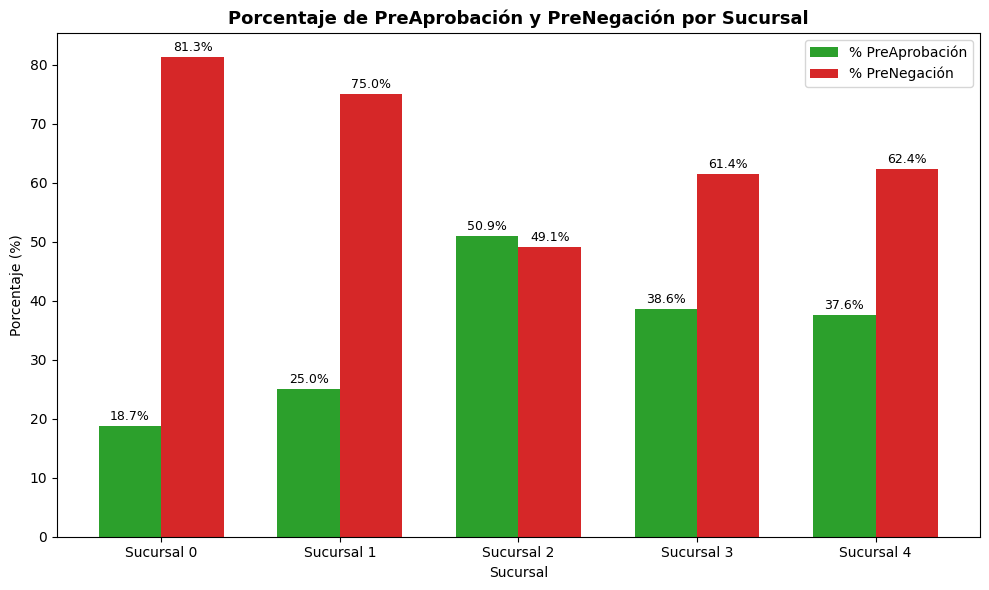

In [ ]:
#Gráfico de barras agrupadas para PreAprobación y PreNegación
x = np.arange(5)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, PA, width, label='% PreAprobación', color='#2ca02c')
bars2 = ax.bar(x + width/2, PN, width, label='% PreNegación', color='#d62728')

ax.set_xlabel('Sucursal')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Porcentaje de PreAprobación y PreNegación por Sucursal', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Sucursal {j}' for j in range(5)])
ax.legend()

#Se agregan las etiquetas de porcentaje
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('preaprobacion_por_sucursal.png', dpi=150, bbox_inches='tight')
plt.show()

# **Análisis de Resultados:**

La aplicación del algoritmo K-Medoids con cinco semillas aleatorias (los primeros cinco solicitantes de la base ofuscada) permitió integrar los 5.842 registros de solicitantes de crédito en cinco sucursales diferenciadas por sus perfiles socioeconómicos y crediticios. El resultado más llamativo es la marcada asimetría en la distribución de la cartera: la Sucursal 2 concentra 5.359 clientes (91,7 % del total), mientras que las cuatro sucursales restantes se reparten apenas el 8,3 % remanente (Sucursal 3 con 215, Sucursal 0 con 123, Sucursal 4 con 101 y Sucursal 1 con 44). Esta concentración podría interpretarse como evidencia de que existe un perfil de cliente "masivo" claramente dominante y cuatro nichos minoritarios con características atípicas que el método logra aislar con éxito.

- Sucursal 2: Los gráficos de araña muestran que esta sucursal domina simultáneamente en casi todas las dimensiones financieras relevantes: es la que registra los valores normalizados más altos en Ingresos, Egresos, Monto (EAD), Cuota (COP), Hijos y Personas a Cargo. Se trata, en esencia, del cliente promedio de la entidad: edad joven-media (27 años en el centroide), capacidad de ingreso y endeudamiento estandarizada, y una base territorial diversificada encabezada por Sabaneta (1.715 solicitantes), Caldas (1.626) y Bello (987). Es también la única sucursal donde el porcentaje de preaprobación (50,91 %) supera al de prenegación (49,09 %), lo que la posiciona como la unidad con mejor desempeño comercial y menor fricción en el proceso de originación.

- Sucursales 0 y 1: Estas dos sucursales comparten una señal de alerta clara, sus tasas de prenegación son las más elevadas del sistema (81,30 % y 75,00 % respectivamente). La Sucursal 0 agrupa perfiles con Monto y Plazo elevados pero con desempeño crediticio deficiente, lo cual sugiere solicitudes de crédito ambiciosas frente a una capacidad de pago insuficiente. La Sucursal 1, la más pequeña con solo 44 clientes, se distingue por un estrato alto y plazos largos, pero con apenas 25 % de preaprobación. En conjunto, estas dos sucursales representan el segmento donde la entidad debe reforzar los filtros de originación y revisar los criterios de scoring, pues concentran el riesgo sin aportar volumen significativo.

- Sucursales 3 y 4: La Sucursal 3 (215 clientes) se caracteriza por un centroide dominado por la variable Edad (62,6 años), configurándose como el cluster de clientes adultos mayores, con montos y cuotas modestos y una tasa de preaprobación del 38,60 %. La Sucursal 4 (101 clientes) presenta un perfil muy particular marcado por Estrato alto y plazos largos, con 37,62 % de preaprobación. Ambos clusters representan nichos con rentabilidad moderada y riesgo controlado, útiles para segmentación comercial diferenciada pero sin el peso estratégico de la Sucursal 2.

El análisis municipal confirma que la cartera se concentra en el sur del Valle de Aburrá. Caldas aparece como el municipio predominante en cuatro de las cinco sucursales (0, 1, 3 y 4), mientras que Sabaneta lidera en la Sucursal 2. Medellín, pese a ser el principal centro urbano, registra una participación marginal en todos los clusters, lo que sugiere que la entidad opera como un actor de nicho enfocado en municipios conurbados más que en la capital departamental. Esta lectura territorial debe incorporarse a la decisión de localización física de las cinco sucursales resultantes.

El ejercicio confirma la viabilidad de consolidar la operación en cinco sucursales, pero evidencia que una de ellas (Sucursal 2) deberá asumir una carga operativa desproporcionada y, por lo tanto, requerirá mayor dotación de personal, infraestructura y capacidad tecnológica. Las Sucursales 0 y 1 ameritan una revisión crítica: dada su escala reducida y sus altas tasas de prenegación, la entidad podría evaluar si conviene mantenerlas como unidades independientes o fusionarlas bajo un esquema de atención especializada en perfiles de mayor riesgo.